In [1]:
# 1) Imports & Settings
import os, warnings, math, sys, json, random, platform
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

SEED = 42
np.random.seed(SEED); random.seed(SEED)


In [2]:
# 2) MLflow config
TRACKING_URI = "http://127.0.0.1:5001"
EXPERIMENT_NAME = "churn-prod"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", TRACKING_URI)
print("Experiment:", EXPERIMENT_NAME)


2025/09/26 05:13:25 INFO mlflow.tracking.fluent: Experiment with name 'churn-prod' does not exist. Creating a new experiment.


Tracking URI: http://127.0.0.1:5001
Experiment: churn-prod


In [3]:
# 3) Data synthesis (70/30 imbalance)
X, y = make_classification(
    n_samples=5000,
    n_features=30,
    n_informative=12,
    n_redundant=5,
    n_classes=2,
    weights=[0.7, 0.3],
    class_sep=1.0,
    flip_y=0.01,
    random_state=SEED
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)


In [4]:
# 4) RandomizedSearchCV with RepeatedStratifiedKFold
base_rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    bootstrap=True
)

param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [None, 6, 8, 12, 16],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    random_state=SEED,
    refit=True
)

search.fit(X_train, y_train)
best_rf = search.best_estimator_
print("Best params:", search.best_params_)


Best params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 12}


In [5]:
# 5) Probability calibration
calibrated = CalibratedClassifierCV(best_rf, method="isotonic", cv=3)
calibrated.fit(X_train, y_train)

proba = calibrated.predict_proba(X_test)[:, 1]
preds_default = (proba >= 0.5).astype(int)

macro_f1 = f1_score(y_test, preds_default, average="macro")
ap = average_precision_score(y_test, proba)
roc = roc_auc_score(y_test, proba)
acc = accuracy_score(y_test, preds_default)


In [6]:
# 6) Threshold tuning via PR curve
prec, rec, th = precision_recall_curve(y_test, proba)
f1s = 2 * (prec*rec) / (prec+rec + 1e-12)
best_idx = int(np.nanargmax(f1s[:-1]))
best_threshold = th[best_idx]

preds_tuned = (proba >= best_threshold).astype(int)
macro_f1_tuned = f1_score(y_test, preds_tuned, average="macro")
acc_tuned = accuracy_score(y_test, preds_tuned)


Successfully registered model 'churn-prod-model'.
2025/09/26 05:30:02 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: churn-prod-model, version 1
Created version '1' of model 'churn-prod-model'.


🏃 View run churn_prod at: http://127.0.0.1:5001/#/experiments/3/runs/fee38a2cc10848f087199772fd5e64e7
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
Run logged and registered.


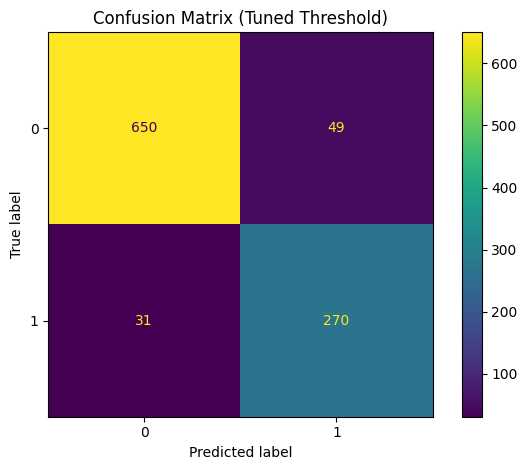

In [9]:
# 7) MLflow logging
run_name = "churn_prod"

with mlflow.start_run(run_name=run_name) as run:
    # metrics
    mlflow.log_metric("macro_f1_default", float(macro_f1))
    mlflow.log_metric("pr_auc", float(ap))
    mlflow.log_metric("roc_auc", float(roc))
    mlflow.log_metric("accuracy_default", float(acc))
    mlflow.log_metric("threshold_best_f1", float(best_threshold))
    mlflow.log_metric("macro_f1_tuned", float(macro_f1_tuned))
    mlflow.log_metric("accuracy_tuned", float(acc_tuned))

    # params
    for k, v in best_rf.get_params().items():
        if isinstance(v, (str, int, float, bool)) or v is None:
            mlflow.log_param(f"rf__{k}", v)

    # confusion matrix
    fig = plt.figure()
    ConfusionMatrixDisplay.from_predictions(y_test, preds_tuned)
    plt.title("Confusion Matrix (Tuned Threshold)")
    plt.tight_layout()
    mlflow.log_figure(fig, "plots/confusion_matrix_tuned.png")
    plt.close(fig)

    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    fig = plt.figure()
    plt.plot(fpr, tpr, label=f"ROC-AUC={roc:.3f}")
    plt.plot([0,1],[0,1],"--")
    plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR")
    mlflow.log_figure(fig, "plots/roc_curve.png")
    plt.close(fig)

    # PR
    fig = plt.figure()
    plt.plot(rec, prec, label=f"PR-AUC={ap:.3f}")
    plt.legend(); plt.xlabel("Recall"); plt.ylabel("Precision")
    mlflow.log_figure(fig, "plots/pr_curve.png")
    plt.close(fig)

    # Feature importances
    importances = best_rf.feature_importances_
    idx = np.argsort(importances)[::-1][:15]
    fig = plt.figure()
    plt.bar(range(len(idx)), importances[idx])
    plt.xticks(range(len(idx)), [f"f{int(i)}" for i in idx], rotation=45, ha="right")
    plt.title("Top-15 Feature Importances")
    mlflow.log_figure(fig, "plots/feature_importances_top15.png")
    plt.close(fig)

    # Model + signature
    sig = infer_signature(X_train, calibrated.predict_proba(X_train)[:,1])
    mlflow.sklearn.log_model(
        sk_model=calibrated,
        name="model",
        signature=sig,
        input_example=X_train[:5],
        registered_model_name="churn-prod-model"
    )

    # Tags
    mlflow.set_tag("owner", "raghu")
    mlflow.set_tag("purpose", "demo_prod_churn")
    mlflow.set_tag("dataset", "synthetic_70_30")
    mlflow.set_tag("git_commit", os.getenv("GIT_COMMIT", "unknown"))
    mlflow.set_tag("python_version", platform.python_version())
    mlflow.set_tag("platform", platform.platform())
    mlflow.set_tag("run_status", "success")

print("Run logged and registered.")
